In [1]:
import xgboost, dask, distributed, sys

print("xgboost:", xgboost.__version__)
print("dask:", dask.__version__)
print("distributed:", distributed.__version__)
print("python:", sys.version)

xgboost: 2.1.4
dask: 2024.12.1
distributed: 2024.12.1
python: 3.11.12 (main, Apr  9 2025, 08:55:55) [GCC 13.3.0]


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from newutils.data.datasets import load_train_subset, add_lags
from newutils.other.helpers import init_context
from oldutils.types import TimeRange
from oldutils.datasets import ARTIFACTS_FOLDER

init_context()

In [4]:
HORIZON_HISTORY = TimeRange.YEAR
HORIZON_FORECAST = TimeRange.WEEK

COL_GAUGE_ID = "gauge_id"
TARGETS = ["q_mm_day"]

In [5]:
df = load_train_subset()

In [6]:
lags = range(1, HORIZON_HISTORY + 1)
lags_columns = ["prcp", "t_max", "t_min", "t_mean", "q_mm_day", "lvl_sm"]
df = add_lags(df, lags_columns, lags)

In [7]:
targets = []
df = add_lags(df, targets, range(1, HORIZON_FORECAST + 1), targets)
targets.extend(TARGETS)

In [8]:
df = df.dropna()

In [9]:
from oldutils.datasets import STATIC_FEATURES
from oldutils.datasets import HydroStaticFeaturesFiles
import dask.dataframe as dd

hsff = HydroStaticFeaturesFiles().dataframe.collect().to_pandas()[STATIC_FEATURES + ["gauge_id"]]
hsff = dd.from_pandas(hsff)
df = df.merge(hsff, how="left", on="gauge_id")
df.head()

,gauge_id,date,prcp,t_max,t_mean,t_min,q_mm_day,lvl_sm,prcp_1,prcp_2,...,gwt_cm_sav,lkv_mc_usu,rev_mc_usu,sgr_dk_sav,slp_dg_sav,ws_area,ele_mt_sav,height_bs,lat,lon
0,3156,2008-12-31,0.562534,-15.878699,-16.935305,-18.358683,0.040575,145.0,0.745000,2.316464,...,82.542072,4.507596,0.011849,96.133805,4.842305,32792.589,376.747185,173.14,60.967299,115.483
1,3156,2009-01-01,1.948758,-11.576528,-14.122068,-16.907592,0.040575,145.0,0.562534,0.745000,...,82.542072,4.507596,0.011849,96.133805,4.842305,32792.589,376.747185,173.14,60.967299,115.483
2,3156,2009-01-02,0.847689,-12.008045,-13.176192,-14.185360,0.040575,145.0,1.948758,0.562534,...,82.542072,4.507596,0.011849,96.133805,4.842305,32792.589,376.747185,173.14,60.967299,115.483
3,3156,2009-01-03,2.026369,-11.371572,-13.134478,-15.661844,0.040575,145.0,0.847689,1.948758,...,82.542072,4.507596,0.011849,96.133805,4.842305,32792.589,376.747185,173.14,60.967299,115.483
4,3156,2009-01-04,0.354133,-15.930996,-19.105313,-22.210526,0.040312,145.0,2.026369,0.847689,...,82.542072,4.507596,0.011849,96.133805,4.842305,32792.589,376.747185,173.14,60.967299,115.483


In [10]:
X = df.drop(columns=set(lags_columns + ["q_mm_day"] + ["date"]))
y = df[targets]
X_train, y_train = X, y

# Model

In [11]:
from dask.distributed import Client, LocalCluster, wait
import dask

# dask.config.set(scheduler="processes")

# from dask_cuda import LocalCUDACluster
import gc

# try:
#     client.close()
#     cluster.close()
#     print("Delete")
# except NameError:
#     print("Nothing")
#     pass
# gc.collect()

# cluster = LocalCluster(dashboard_address=":8789", asynchronous=True)
# # cluster = LocalCUDACluster(CUDA_VISIBLE_DEVICES="0", n_workers=1, dashboard_address=":8789")
# client = cluster.get_client()
# client = Client()

# print(cluster)
# print(client)

In [13]:
import dask.array as da
import pandas as pd
import numpy as np
import dask.dataframe as dd
import xgboost.dask as dxgb
import warnings

params = {
    "tree_method": "hist",
    "learning_rate": 0.1,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

EPS = 1e-6


def mape_obj(preds, dmat):
    y = dmat.get_label()
    grad = np.sign(preds - y) / (np.abs(y) + EPS)
    hess = EPS / (np.abs(y) + EPS) ** 2
    return grad, hess


# async def main():
def main():
    try:
        client.close()
        cluster.close()
        print("Deleted previous client and cluster")
    except NameError:
        print("Nothing to delete")
    gc.collect()

    # 3. Start cluster & client in async mode
    # async
    with LocalCluster(
        dashboard_address=":8789",
        asynchronous=False,
        n_workers=2,
        threads_per_worker=1,
        memory_limit="4 GiB",
        processes=True,
    ) as cluster:
        # async
        with Client(cluster, asynchronous=False) as client:
            print("Dask client running in async mode:", client)
            warnings.filterwarnings("ignore")

            # 5. Build the DaskDMatrix and train
            # X_trainp, y_trainp = await client.persist([X_train, y_train])
            print("Prepare datasets...")
            with warnings.catch_warnings(record=True) as caught_warnings:
                X_trainp, y_trainp = client.persist([X_train, y_train])
                wait([X_trainp, y_trainp])
            print("Create train set...")
            dtrain = dxgb.DaskDMatrix(client, X_trainp, y_trainp)
            print("Train model...")
            # booster, training_history = await dxgb.train(
            results = dxgb.train(
                client,
                params,
                dtrain,
                num_boost_round=100,
                verbose_eval=10,
                obj=mape_obj,
            )
            results["booster"].save_model(ARTIFACTS_FOLDER / "test_save.json")

            print("Training metrics and booster information:")
            print(results["history"])
            print(results["booster"])
    return results


result = main()
print(result)

Nothing to delete
Dask client running in async mode: <Client: 'tcp://127.0.0.1:37453' processes=2 threads=2, memory=8.00 GiB>
Prepare datasets...
Create train set...
Train model...


[11:40:18] Task [xgboost.dask-1]:tcp://127.0.0.1:39537 got rank 1[11:40:18] Task [xgboost.dask-0]:tcp://127.0.0.1:41585 got rank 0



Training metrics and booster information:
{}
{'booster': <xgboost.core.Booster object at 0x7ad1d12c9d90>, 'history': {}}


In [14]:
X_test = X.get_partition(0).compute()

In [15]:
import xgboost as xgb
import shap

booster = xgb.Booster()

booster.load_model(ARTIFACTS_FOLDER / "test_save.json")

# dtest = xgb.DMatrix(data=X_train)
# preds = booster.predict(dtest)

explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test)

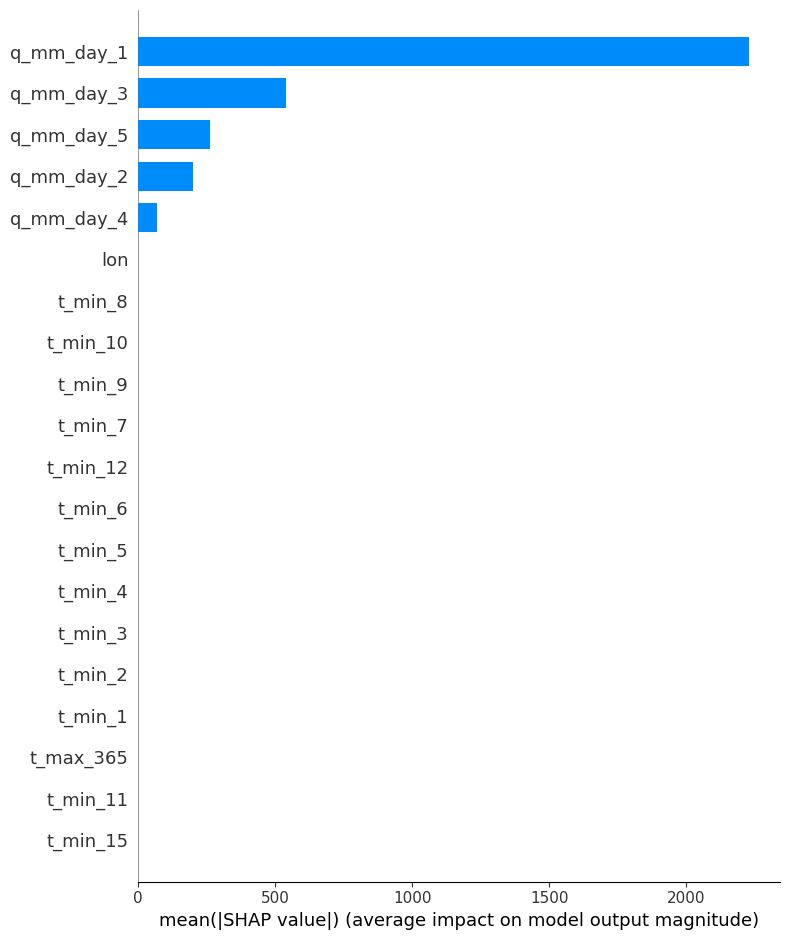

In [16]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

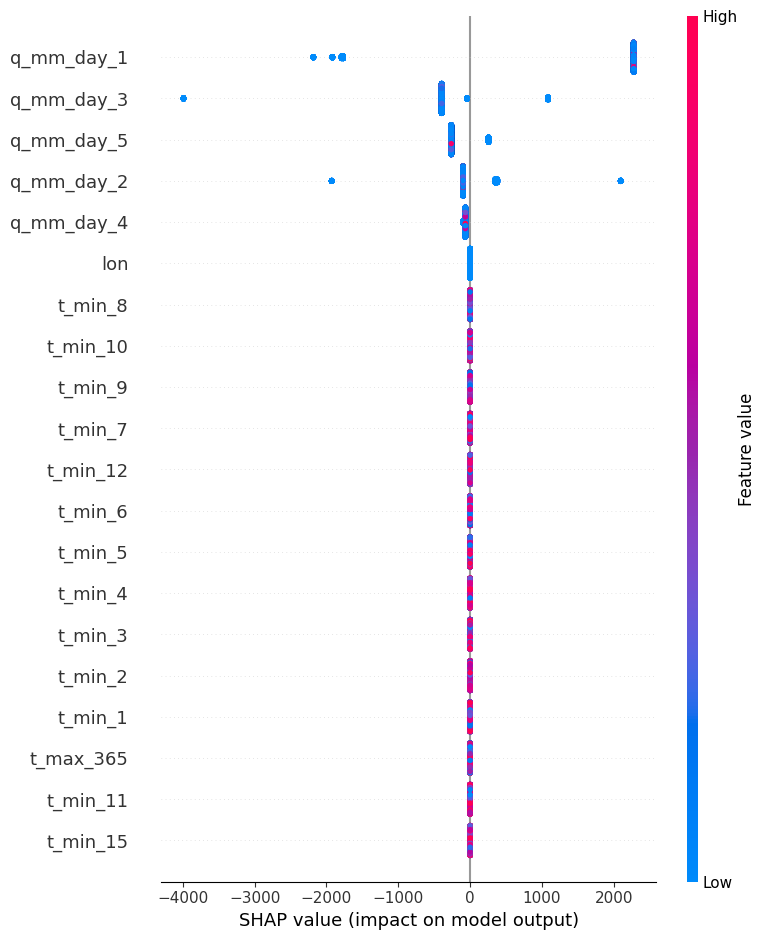

In [17]:
shap.summary_plot(shap_values, X_test)

In [18]:
import gc

client.close()
cluster.close()
gc.collect()

NameError: name 'client' is not defined